# Evaluating a New Recommender System with an A/B Test
**Irene Undiandeye**

## Task

An international online store launched an A/B test of an improved recommendation system, but the analyst who set it up left before analysing it, leaving only the technical specification and the raw data. This notebook checks whether the test was carried out correctly and then analyses its results.

According to the specification, the test `recommender_system_test` compared group A (control) with group B (new recommendation system). New users were enrolled from 7 to 21 December 2020 and the test was due to end on 1 January 2021. The audience was 15% of new users from the EU region, with an expected 6,000 participants. The expected result was that, within 14 days of signing up, users in group B would convert at least 10% better at each stage of the funnel: product page views (`product_page`), product card views (`product_cart` in the data) and purchases (`purchase`).

## Contents

1. Data loading and preparation
2. Checking whether the test was run correctly
3. Building the analysis sample
4. Funnel conversion by group
5. Hypothesis testing
6. Statistical power
7. Robustness check
8. Conclusions and recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 110

## 1. Data Loading and Preparation

In [2]:
marketing = pd.read_csv('ab_project_marketing_events_us.csv', parse_dates=['start_dt', 'finish_dt'])
users = pd.read_csv('final_ab_new_users_upd_us.csv', parse_dates=['first_date'])
events = pd.read_csv('final_ab_events_upd_us.csv', parse_dates=['event_dt'])
participants = pd.read_csv('final_ab_participants_upd_us.csv')

for name, df in [('marketing', marketing), ('users', users), ('events', events), ('participants', participants)]:
    print(f"{name:13s} rows: {len(df):>7,}  missing values: {df.isna().sum().sum():>7,}  duplicate rows: {df.duplicated().sum()}")

marketing     rows:      14  missing values:       0  duplicate rows: 0
users         rows:  58,703  missing values:       0  duplicate rows: 0
events        rows: 423,761  missing values: 363,447  duplicate rows: 0
participants  rows:  14,525  missing values:       0  duplicate rows: 0


The only missing values are in the `details` column of the events table, which records the purchase amount and is therefore empty for non-purchase events. This is expected and needs no cleaning. There are no fully duplicated rows. Importantly, a user having many events is not a data error: each row is one action, and the analysis below counts each user once per funnel stage rather than removing repeated events.

In [3]:
events['event_name'].value_counts()

event_name
login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: count, dtype: int64

## 2. Checking Whether the Test Was Run Correctly

Before interpreting any result, it is necessary to verify that the test followed its specification. A flawed test can produce misleading conclusions regardless of the statistics applied to it.

### 2.1 Overlap with another test

In [4]:
participants.groupby('ab_test')['group'].value_counts().unstack()

group,A,B
ab_test,,
interface_eu_test,5467,5383
recommender_system_test,2747,928


In [5]:
rec = participants[participants['ab_test'] == 'recommender_system_test'][['user_id', 'group']]
interface = participants[participants['ab_test'] == 'interface_eu_test']

overlap = rec.merge(interface[['user_id', 'group']], on='user_id', suffixes=('_rec', '_interface'))
print(f"Users in the recommender test: {len(rec):,}")
print(f"Users also enrolled in interface_eu_test: {len(overlap):,} ({len(overlap)/len(rec):.1%})")
print(f"Users in both groups of the recommender test: {(rec.groupby('user_id')['group'].nunique() > 1).sum()}")
pd.crosstab(overlap['group_rec'], overlap['group_interface'], margins=True)

Users in the recommender test: 3,675
Users also enrolled in interface_eu_test: 887 (24.1%)
Users in both groups of the recommender test: 0


group_interface,A,B,All
group_rec,,,
A,340,325,665
B,116,106,222
All,456,431,887


No user appears in both groups of the recommender test, but 887 participants (24%) were also enrolled in a second experiment, `interface_eu_test`, that ran at the same time. Users who were in group B of that test saw a changed interface, which could affect their behaviour independently of the recommendation system. These users are excluded from the main analysis, and a robustness check in Section 7 excludes all overlapping users.

### 2.2 Audience

In [6]:
rec_users = rec.merge(users, on='user_id')
print(rec_users['region'].value_counts())

eu_new = users[(users['region'] == 'EU') & users['first_date'].between('2020-12-07', '2020-12-21')]
eu_in_test = rec_users[rec_users['region'] == 'EU']
print(f"\nNew EU users during enrolment: {len(eu_new):,}")
print(f"EU users enrolled in the test: {len(eu_in_test):,} ({len(eu_in_test)/len(eu_new):.1%} of new EU users; target 15%)")

region
EU           3481
N.America     119
APAC           45
CIS            30
Name: count, dtype: int64

New EU users during enrolment: 39,466
EU users enrolled in the test: 3,481 (8.8% of new EU users; target 15%)


The test was meant for EU users only, yet 194 participants come from other regions; they are excluded. Only 8.8% of new EU users were enrolled rather than the specified 15%, and the total of 3,675 participants falls well short of the expected 6,000.

### 2.3 Sample ratio mismatch

In [7]:
counts = rec['group'].value_counts()
stat, p = chisquare(counts)
print(counts)
print(f"\nShare in group B: {counts['B']/counts.sum():.1%}")
print(f"Chi-square test against an equal split: statistic = {stat:.1f}, p-value = {p:.2e}")

group
A    2747
B     928
Name: count, dtype: int64

Share in group B: 25.3%
Chi-square test against an equal split: statistic = 900.3, p-value = 8.26e-198


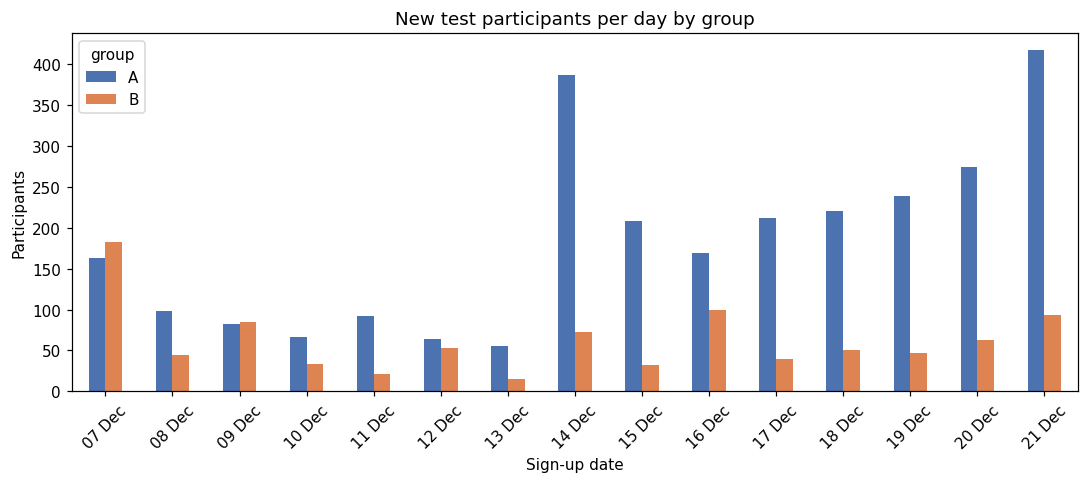

In [8]:
daily = rec_users.groupby(['first_date', 'group'])['user_id'].count().unstack()
daily.index = daily.index.strftime('%d %b')
ax = daily.plot(kind='bar', figsize=(10, 4.5), color=['#4c72b0', '#dd8452'])
ax.set_title('New test participants per day by group')
ax.set_xlabel('Sign-up date')
ax.set_ylabel('Participants')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Group B contains only 25% of participants, and the chi-square test rejects an equal split with overwhelming confidence. The imbalance is present on every enrolment day. A sample ratio mismatch of this size usually signals a fault in how users were assigned to groups, which means the two groups may not be comparable. This is the most serious problem with the test.

### 2.4 Test period and marketing activity

In [9]:
print(f"First event: {events['event_dt'].min()}")
print(f"Last event:  {events['event_dt'].max()}")
print("\nEvents per day in the final days of the data:")
print(events['event_dt'].dt.date.value_counts().sort_index().tail(8))

First event: 2020-12-07 00:00:33
Last event:  2020-12-30 23:36:33

Events per day in the final days of the data:
event_dt
2020-12-22    29472
2020-12-23    26108
2020-12-24    19399
2020-12-26    14058
2020-12-27    12420
2020-12-28    11014
2020-12-29    10146
2020-12-30       89
Name: count, dtype: int64


In [10]:
marketing[(marketing['start_dt'] <= '2021-01-01') & (marketing['finish_dt'] >= '2020-12-07')]

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07


The data stops on 30 December, two days before the planned end of the test, and there are no events at all on 25 December. Users who signed up near the end of enrolment therefore had fewer than 14 days observed. The Christmas & New Year Promo began in the EU on 25 December, inside the test window; because it applied to both groups and activity after that date is low, it is unlikely to bias the comparison, but it may have made behaviour less typical.

## 3. Building the Analysis Sample

The analysis sample contains EU participants of the recommender test who were not in group B of the interface test. For each user, only events within 14 days of sign-up are counted, as the specification requires.

In [11]:
interface_b = set(interface.loc[interface['group'] == 'B', 'user_id'])

def build_sample(exclude_ids):
    sample = rec_users[(rec_users['region'] == 'EU') & ~rec_users['user_id'].isin(exclude_ids)]
    ev = events.merge(sample[['user_id', 'group', 'first_date']], on='user_id')
    ev = ev[ev['event_dt'] < ev['first_date'] + pd.Timedelta(days=14)]
    return sample, ev

sample, sample_events = build_sample(interface_b)
group_sizes = sample['group'].value_counts().sort_index()
print(group_sizes)
print(f"\nUsers with at least one event in the window: {sample_events['user_id'].nunique():,} of {len(sample):,}")

group
A    2279
B     771
Name: count, dtype: int64

Users with at least one event in the window: 3,050 of 3,050


## 4. Funnel Conversion by Group

In [12]:
stages = ['product_page', 'product_cart', 'purchase']

def funnel(sample_events, group_sizes):
    converted = (sample_events[sample_events['event_name'].isin(stages)]
                 .groupby(['event_name', 'group'])['user_id'].nunique()
                 .unstack().reindex(stages))
    rates = converted.div(group_sizes, axis=1)
    return converted, rates

converted, rates = funnel(sample_events, group_sizes)
table = pd.DataFrame({
    'Users A': converted['A'], 'Users B': converted['B'],
    'Conversion A': rates['A'], 'Conversion B': rates['B'],
    'Relative change (B vs A)': rates['B'] / rates['A'] - 1
})
table

,Users A,Users B,Conversion A,Conversion B,Relative change (B vs A)
event_name,,,,,
product_page,1476,429,0.6477,0.5564,-0.1409
product_cart,686,214,0.3010,0.2776,-0.0779
purchase,734,219,0.3221,0.2840,-0.1181


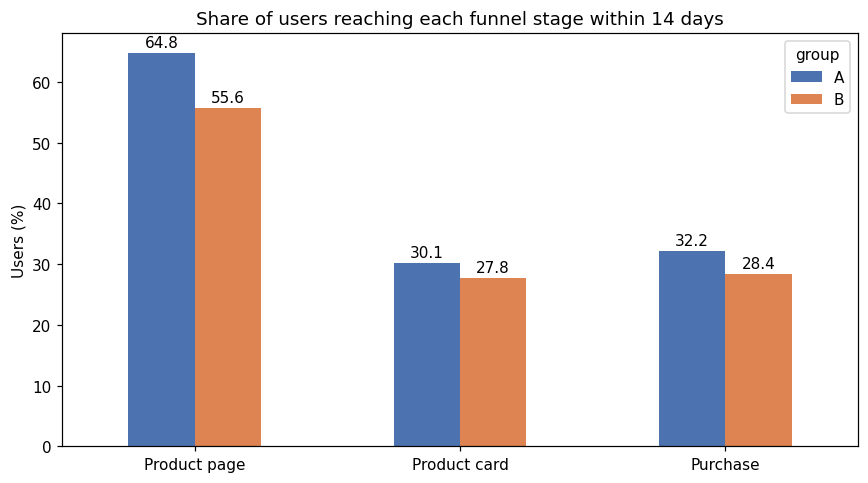

In [13]:
ax = (rates * 100).plot(kind='bar', figsize=(8, 4.5), color=['#4c72b0', '#dd8452'])
ax.set_title('Share of users reaching each funnel stage within 14 days')
ax.set_ylabel('Users (%)')
ax.set_xlabel('')
ax.set_xticklabels(['Product page', 'Product card', 'Purchase'], rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2)
plt.tight_layout()
plt.show()

Conversion in group B is lower than in group A at every stage, the opposite of the expected 10% improvement. Note that the purchase rate is slightly higher than the product card rate in both groups, which suggests that some purchases can be completed without the product card step, so the stages are best compared individually rather than as a strict sequence.

## 5. Hypothesis Testing

For each funnel stage, a two-proportion z-test compares the share of users in each group who reached that stage.

H₀: the conversion rate at this stage is the same in groups A and B.
H₁: the conversion rate at this stage differs between groups A and B.

Because three stages are tested, a Bonferroni correction is applied, giving a significance threshold of 0.05 / 3 ≈ 0.0167 for each test. A two-sided test is used so that a decline in group B can be detected as well as an improvement.

In [14]:
alpha = 0.05 / len(stages)

def run_tests(converted, group_sizes):
    rows = []
    for stage in stages:
        a, b = converted.loc[stage, 'A'], converted.loc[stage, 'B']
        na, nb = group_sizes['A'], group_sizes['B']
        z, p = proportions_ztest([b, a], [nb, na])
        low, high = confint_proportions_2indep(b, nb, a, na, compare='diff', alpha=alpha)
        rows.append({'Stage': stage, 'Difference (B - A)': b/nb - a/na,
                     'CI low': low, 'CI high': high, 'z': z, 'p-value': p,
                     'Significant': p < alpha})
    return pd.DataFrame(rows).set_index('Stage')

results = run_tests(converted, group_sizes)
results

,Difference (B - A),CI low,CI high,z,p-value,Significant
Stage,,,,,,
product_page,-0.0912,-0.1403,-0.0425,-4.5222,0.0000,True
product_cart,-0.0234,-0.0671,0.0226,-1.2340,0.2172,False
purchase,-0.0380,-0.0822,0.0084,-1.9691,0.0489,False


The decline in product page views in group B, about 9 percentage points or 14% in relative terms, is statistically significant even after the Bonferroni correction. The differences for product card views and purchases are not significant at the corrected threshold; the purchase difference would only just pass an uncorrected 0.05 threshold (p = 0.049), which is exactly the kind of borderline result the correction is designed to guard against. At no stage is there evidence of the expected improvement; the confidence intervals (adjusted to match the corrected threshold) for product page views lie entirely below zero.

## 6. Statistical Power

A non-significant result is only informative if the test was large enough to detect the effect it was designed to find. The calculation below estimates the probability that a test of this size would detect a true 10% relative improvement at each stage.

In [15]:
power_rows = []
for stage in stages:
    base = rates.loc[stage, 'A']
    effect = proportion_effectsize(base * 1.10, base)
    actual = NormalIndPower().power(effect, nobs1=group_sizes['A'], ratio=group_sizes['B'] / group_sizes['A'], alpha=alpha)
    planned = NormalIndPower().power(effect, nobs1=3000, ratio=1, alpha=alpha)
    power_rows.append({'Stage': stage, 'Baseline conversion': base,
                       'Power with actual groups': actual, 'Power with planned 3,000 per group': planned})
pd.DataFrame(power_rows).set_index('Stage')

,Baseline conversion,Power with actual groups,"Power with planned 3,000 per group"
Stage,,,
product_page,0.6477,0.8270,0.9986
product_cart,0.3010,0.2006,0.5454
purchase,0.3221,0.2238,0.5961


For product card views and purchases, the test as run had only about a 20% chance of detecting a genuine 10% improvement, far below the conventional 80%. Even the planned design of 3,000 users per group would have reached only about 55 to 60% power for these stages. The non-significant results for these two stages are therefore inconclusive rather than evidence that the new system has no effect.

## 7. Robustness Check

The analysis is repeated excluding every user who was enrolled in the interface test, regardless of group.

In [16]:
all_interface = set(interface['user_id'])
sample_r, events_r = build_sample(all_interface)
sizes_r = sample_r['group'].value_counts().sort_index()
converted_r, rates_r = funnel(events_r, sizes_r)
print(sizes_r)
run_tests(converted_r, sizes_r)

group
A    1939
B     655
Name: count, dtype: int64


,Difference (B - A),CI low,CI high,z,p-value,Significant
Stage,,,,,,
product_page,-0.0921,-0.1453,-0.0394,-4.2186,0.0000,True
product_cart,-0.0228,-0.0703,0.0273,-1.1054,0.2690,False
purchase,-0.0245,-0.0726,0.0261,-1.1741,0.2404,False


The conclusions are unchanged: product page views remain significantly lower in group B, and neither product card views nor purchases show a significant difference.

## 8. Conclusions and Recommendations

The test did not deliver the expected result. Within 14 days of sign-up, users who received the new recommendation system were significantly less likely to view product pages, with a relative decline of about 14%, and there is no evidence of any improvement in product card views or purchases. None of the three stages reached the target increase of 10%.

However, the test itself was not run according to its specification, and these results should not be treated as a final verdict on the new system. Group B received only a quarter of participants instead of half, a sample ratio mismatch that points to a fault in group assignment and means the groups may not be comparable. A quarter of participants were simultaneously enrolled in another experiment. Only 8.8% of new EU users were enrolled rather than 15%, the sample reached 3,675 users instead of 6,000, some participants came from outside the EU, and the data ends before the planned finish date. As a result, the test was badly underpowered for the purchase and product card stages.

The decline in product page views is nonetheless a clear warning sign that justifies not rolling out the new recommendation system in its current form. The company should investigate why fewer group B users reached product pages, fix the assignment mechanism so that users are split evenly at random, and rerun the test with no overlapping experiments, the full EU audience share, a period that avoids major holiday promotions, and a sample size calculated in advance to give at least 80% power for the purchase stage.